### Домашка 1. Гречин Андрій

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("image.png")
img.shape

(1042, 1556, 3)

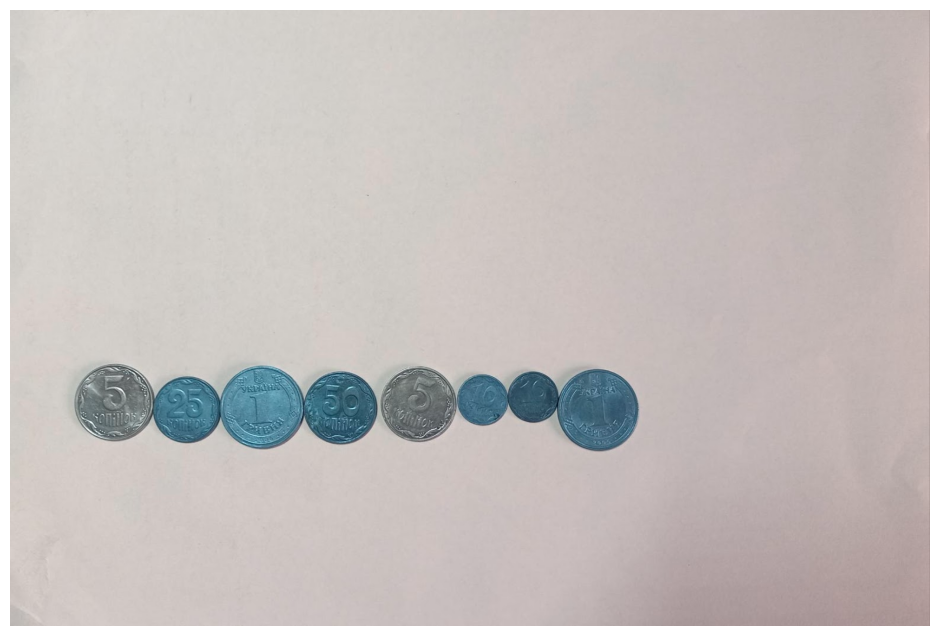

In [3]:
plt.figure(figsize=(12, 8))
plt.axis(False)
plt.imshow(img)

In [4]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

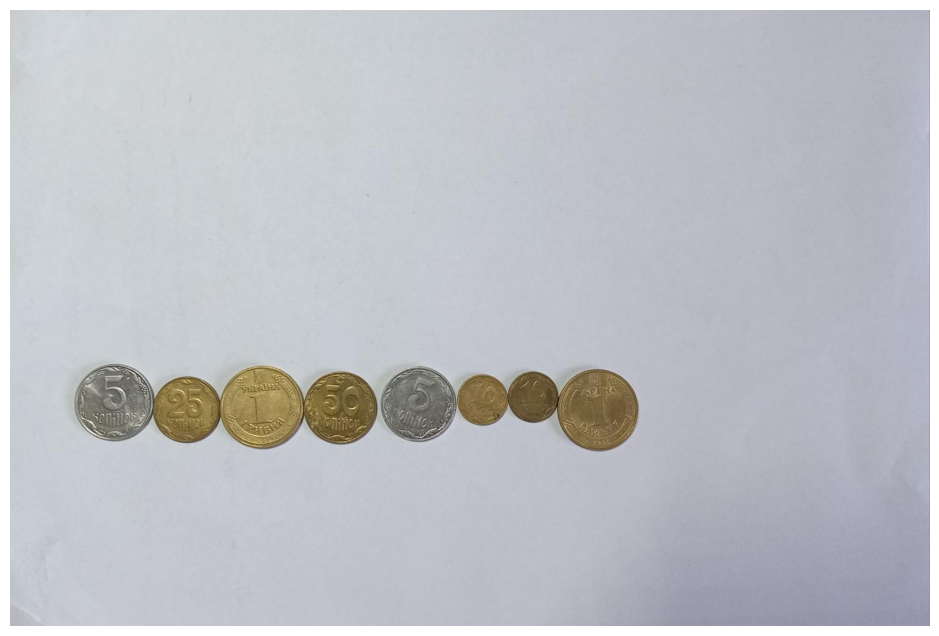

In [5]:
plt.figure(figsize=(12, 8))
plt.axis(False)
plt.imshow(img_rgb)

In [6]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

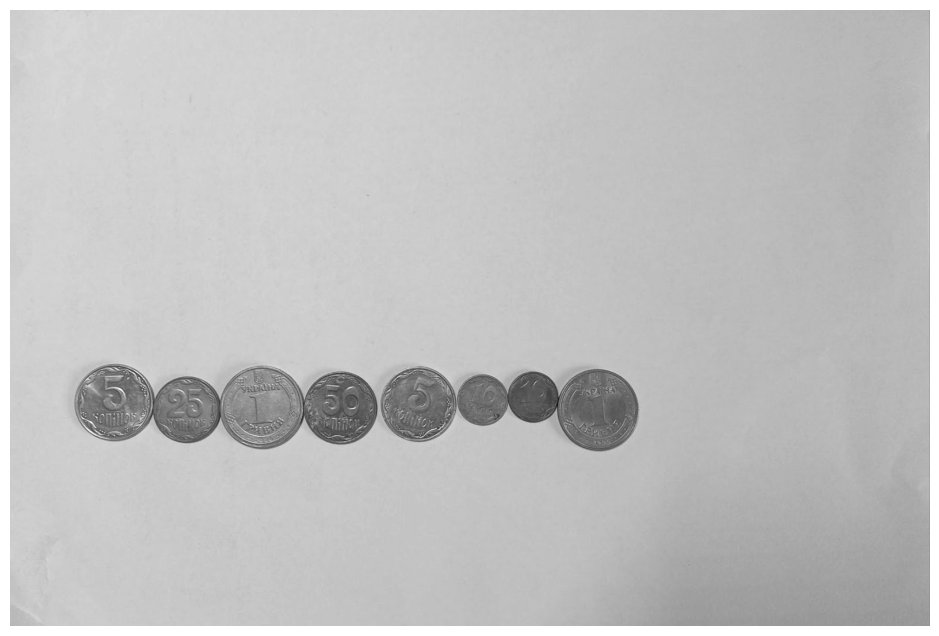

In [7]:
plt.figure(figsize=(12, 8))
plt.axis(False)
plt.imshow(gray, cmap="gray")

### Варіант 1 (просто класично) +++ норм гарно радіуси рахувати, я собі це уявляв як розподіл Гауса

In [28]:
from scipy import ndimage as ndi


img1 = cv2.imread("image.png")
img1 = img1[:900, :]

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

blur1 = cv2.GaussianBlur(gray1, (5, 5), 0)
_, binary1 = cv2.threshold(blur1, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
opened = cv2.morphologyEx(binary1, cv2.MORPH_OPEN, kernel, iterations=2)

dist_transform = cv2.distanceTransform(opened, cv2.DIST_L2, 5)

min_distance = 60  
size = 2 * min_distance + 1
local_max_mask = (ndi.maximum_filter(dist_transform, size=size) == dist_transform) & (dist_transform > 0)

labeled_peaks, count = ndi.label(local_max_mask, structure=np.ones((3, 3)))
centers = ndi.center_of_mass(local_max_mask, labeled_peaks, range(1, count + 1))

print(f"Кількість монет на зображенні: {count}")

debug = img.copy()
for i, (y, x) in enumerate(centers, 1):
    x, y = int(x), int(y)
    cv2.circle(debug, (x, y), 6, (0, 0, 255), -1)
    cv2.putText(debug, str(i), (x + 10, y), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
cv2.imwrite("debug_variant1_final.png", debug)

Кількість монет на зображенні: 8


True

### Варіант 2 (Через ХАФА) +++ Найкращий варіант

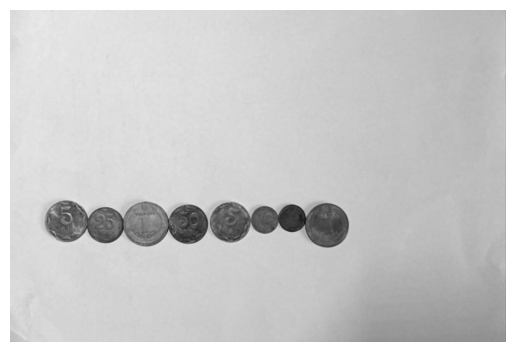

In [9]:
blur = cv2.medianBlur(gray, 5)
plt.axis(False)
plt.imshow(blur, cmap="gray")

In [10]:
circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=80,
        param1=100,
        param2=45,
        minRadius=30,
        maxRadius=75,
    )

show_debug = True

count = 0
if circles is not None:
    circles = np.round(circles[0, :]).astype(int)
    count = len(circles)
    print(f"Знайдено монет (HoughCircles): {count}")

    if show_debug:
        debug = img.copy()
        for (x, y, r) in circles:
            cv2.circle(debug, (x, y), r, (0, 255, 0), 3)
            cv2.circle(debug, (x, y), 3, (0, 0, 255), -1)
        cv2.imwrite("debug_hough_circles.png", debug)
else:
    print("Кіл не знайдено — спробуйте змінити param1/param2/minRadius/maxRadius")

Знайдено монет (HoughCircles): 8


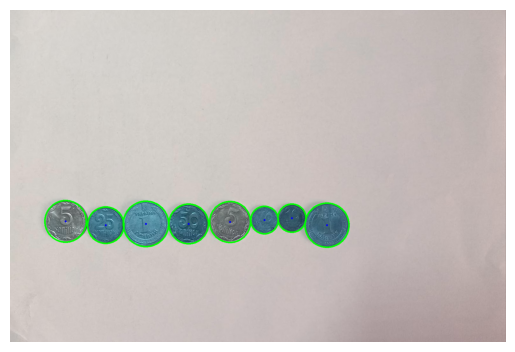

In [11]:
plt.axis(False)
plt.imshow(debug, cmap="gray")

### Варіант 3 (через гістограму?) +++ кака бєка

In [37]:
img3 = cv2.rotate(gray, cv2.ROTATE_90_COUNTERCLOCKWISE)

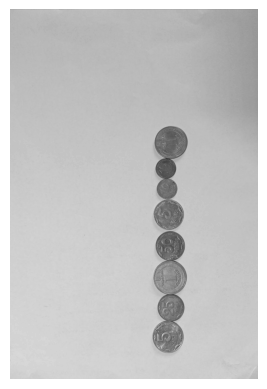

In [38]:
plt.axis(False)
plt.imshow(img3, cmap="gray")

In [39]:
_, binary3 = cv2.threshold(img3, 154, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

In [40]:
kernel3 = np.ones((7, 7), np.uint8)
processed_img3 = cv2.erode(binary3, kernel3, iterations=2)

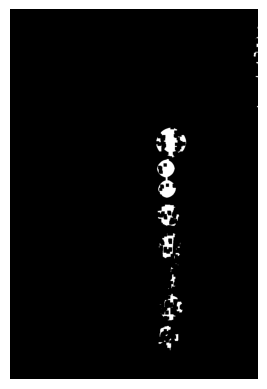

In [41]:
plt.axis(False)
plt.imshow(processed_img3, cmap="gray")

In [42]:
processed_img3 = cv2.dilate(processed_img3, kernel3, iterations=2)

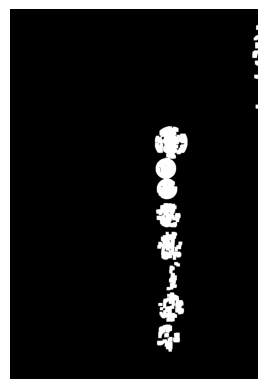

In [43]:
plt.axis(False)
plt.imshow(processed_img3, cmap="gray")

In [44]:
hist3 = np.sum(processed_img3 == 255, axis=1)

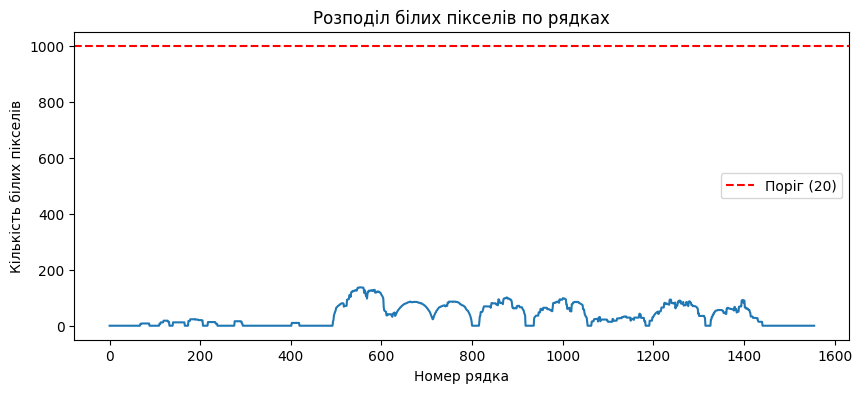

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(hist3)
plt.axhline(y=1000, color='r', linestyle='--', label='Поріг (20)')
plt.title("Розподіл білих пікселів по рядках")
plt.xlabel("Номер рядка")
plt.ylabel("Кількість білих пікселів")
plt.legend()
plt.show()

In [50]:
threshold_value = 34
coin_present = np.where(hist3 > threshold_value, 1, 0)

In [51]:
count = np.sum((coin_present[:-1] == 0) & (coin_present[1:] == 1))
print(f"Кількість монет на зображенні: {count}")

Кількість монет на зображенні: 8


### Варіант 4

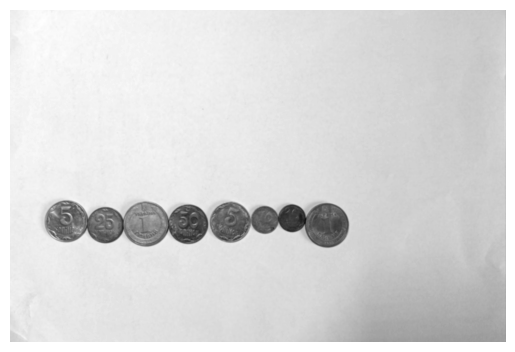

In [52]:
blur4 = cv2.GaussianBlur(gray, (7, 7), 0)
plt.axis(False)
plt.imshow(blur4, cmap="gray")

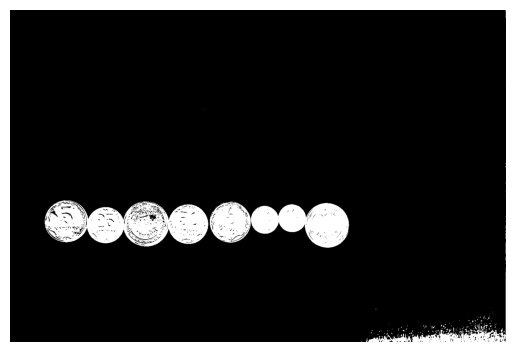

In [53]:
masks, binary4 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.axis(False)
plt.imshow(binary4, cmap="gray")

In [54]:
masks

154.0

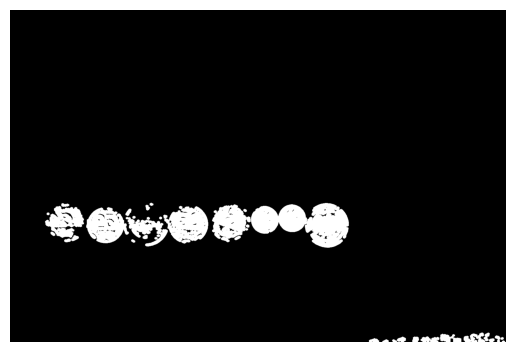

In [55]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
opened4 = cv2.morphologyEx(binary4, cv2.MORPH_OPEN, kernel, iterations=2)

plt.axis(False)
plt.imshow(opened4, cmap="gray")

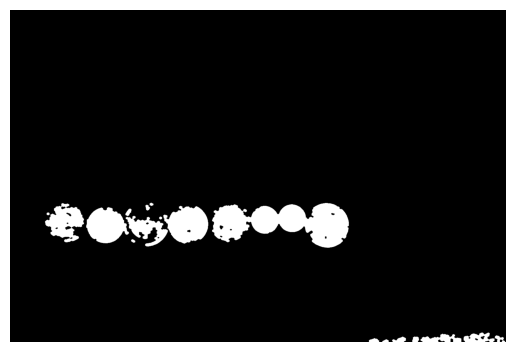

In [56]:
opened4 = cv2.morphologyEx(opened4, cv2.MORPH_CLOSE, kernel, iterations=1)

plt.axis(False)
plt.imshow(opened4, cmap="gray")

In [57]:
contours, _ = cv2.findContours(binary4, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500
max_area = 500000
good_contours = [c for c in contours if min_area < cv2.contourArea(c) < max_area]

print(f"Кількість знайдених контурів (сирих): {len(contours)}")
print(f"Кількість монет після фільтрації: {len(good_contours)}")

Кількість знайдених контурів (сирих): 202
Кількість монет після фільтрації: 5


### Трошки ускладнив таску (монетки на відео) +++

In [35]:
import math
import os

params = {
    'blur_size': 9,
    'blur_sigma': 75,
    'adapt_block': 11,
    'adapt_c': 2,
    'min_area': 250,
    'max_area': 25000,
    'match_dist': 80,
    'separation_threshold': 0.6
}

tracker = {
    'global_transform': np.eye(3, dtype=np.float32),
    'coins': [],
    'next_id': 1,
    'map_size': 2000,
    'map_center': np.array([1000, 1000]),
    'tracking_lost': False
}


def frame_to_global(x, y):
    v = np.array([x, y, 1.0])
    g = tracker['global_transform'] @ v
    return g[0], g[1]


def update_camera_motion(prev_gray, curr_gray):
    if prev_gray is None:
        return False

    mask = np.zeros_like(prev_gray)
    h, w = mask.shape
    mask[60:h - 60, 60:w - 60] = 255

    p0 = cv2.goodFeaturesToTrack(prev_gray, 500, 0.01, 20, mask=mask)
    if p0 is None or len(p0) < 10:
        tracker['tracking_lost'] = True
        return False

    p1, st, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, p0, None,
        winSize=(31, 31), maxLevel=3,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.03)
    )

    good_new = p1[st == 1]
    good_old = p0[st == 1]

    if len(good_new) < 10:
        tracker['tracking_lost'] = True
        return False

    m, _ = cv2.estimateAffinePartial2D(good_old, good_new, method=cv2.RANSAC)
    if m is None:
        tracker['tracking_lost'] = True
        return False

    dx, dy = m[0, 2], m[1, 2]
    if math.hypot(dx, dy) > 150:
        tracker['tracking_lost'] = True
        return False

    m_inv = cv2.invertAffineTransform(m)
    m_3x3 = np.vstack([m_inv, [0, 0, 1]])

    tracker['global_transform'] = tracker['global_transform'] @ m_3x3
    tracker['tracking_lost'] = False
    return True


def recover_position_using_coins(candidates):
    if len(candidates) < 1 or len(tracker['coins']) < 1:
        return

    shifts = []

    for c in candidates:
        gx, gy = frame_to_global(c['x'], c['y'])

        best = None
        best_dist = 1e9
        for k in tracker['coins']:
            if k['seen_count'] < 10:
                continue
            d = math.hypot(gx - k['global_pos'][0], gy - k['global_pos'][1])
            if d < 200 and d < best_dist:
                best_dist = d
                best = k

        if best:
            shifts.append((best['global_pos'][0] - gx,
                           best['global_pos'][1] - gy))

    if shifts:
        shifts = np.array(shifts)
        dx, dy = np.median(shifts[:, 0]), np.median(shifts[:, 1])

        correction = np.eye(3, dtype=np.float32)
        correction[0, 2] = dx
        correction[1, 2] = dy

        tracker['global_transform'] = correction @ tracker['global_transform']
        print(f"!!! АВАРІЙНЕ ВІДНОВЛЕННЯ: ({dx:.1f}, {dy:.1f})")


def correct_map_drift(matches):
    if not matches:
        return

    dx = dy = 0
    for curr, saved in matches:
        dx += saved[0] - curr[0]
        dy += saved[1] - curr[1]

    correction = np.eye(3, dtype=np.float32)
    correction[0, 2] = (dx / len(matches)) * 0.1
    correction[1, 2] = (dy / len(matches)) * 0.1

    tracker['global_transform'] = correction @ tracker['global_transform']


def process_candidates(candidates):
    if tracker['tracking_lost']:
        recover_position_using_coins(candidates)

    matches = []

    for c in candidates:
        gx, gy = frame_to_global(c['x'], c['y'])

        best = None
        best_dist = 1e9
        for k in tracker['coins']:
            d = math.hypot(gx - k['global_pos'][0], gy - k['global_pos'][1])
            if d < best_dist:
                best_dist = d
                best = k

        if best and best_dist < params['match_dist']:
            best['seen_count'] += 1

            if best['seen_count'] > 5:
                matches.append(((gx, gy), best['global_pos']))

            alpha = 0.3 if tracker['tracking_lost'] else 0.05
            best['global_pos'] = (
                best['global_pos'][0] * (1 - alpha) + gx * alpha,
                best['global_pos'][1] * (1 - alpha) + gy * alpha
            )

            c['id'] = best['id']
        else:
            if not c['on_border']:
                tracker['coins'].append({
                    'id': tracker['next_id'],
                    'global_pos': (gx, gy),
                    'radius': c['r'],
                    'seen_count': 1
                })
                c['id'] = tracker['next_id']
                tracker['next_id'] += 1
            else:
                c['id'] = -1

    if not tracker['tracking_lost']:
        correct_map_drift(matches)


def draw_map():
    img = np.zeros((tracker['map_size'], tracker['map_size'], 3), np.uint8) + 30
    count = 0

    for c in tracker['coins']:
        if c['seen_count'] > 5:
            count += 1
            gx, gy = c['global_pos']
            x = int(gx + tracker['map_center'][0])
            y = int(gy + tracker['map_center'][1])
            cv2.circle(img, (x, y), int(c['radius']), (0, 255, 0), 2)
            cv2.putText(img, str(c['id']), (x, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (255, 255, 255), 1)

    status = "LOST" if tracker['tracking_lost'] else "TRACKING"
    color = (0, 0, 255) if tracker['tracking_lost'] else (0, 255, 0)

    cv2.putText(img, f"Status: {status}", (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    cv2.putText(img, f"Total: {count}", (50, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 255), 3)

    return cv2.resize(img, (600, 600))

def process_video(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return

    prev_gray = None
    paused = False

    cv2.namedWindow("Frame", cv2.WINDOW_NORMAL)
    cv2.namedWindow("Map", cv2.WINDOW_NORMAL)
    cv2.createTrackbar("Separation", "Frame", 60, 100, lambda x: None)

    while True:
        if not paused:
            ret, frame = cap.read()
            if not ret:
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            if prev_gray is not None:
                update_camera_motion(prev_gray, gray)
            prev_gray = gray.copy()

            blur = cv2.bilateralFilter(
                gray, params['blur_size'],
                params['blur_sigma'], params['blur_sigma']
            )

            thresh = cv2.adaptiveThreshold(
                blur, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV,
                params['adapt_block'], params['adapt_c']
            )

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
            thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

            clean = np.zeros_like(thresh)
            cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for c in cnts:
                if cv2.contourArea(c) > 500:
                    cv2.drawContours(clean, [cv2.convexHull(c)], -1, 255, -1)

            dist = cv2.distanceTransform(clean, cv2.DIST_L2, 5)
            sep = cv2.getTrackbarPos("Separation", "Frame") / 100.0
            if sep < 0.1:
                sep = 0.5

            _, sure_fg = cv2.threshold(dist, sep * dist.max(), 255, 0)
            sure_fg = np.uint8(sure_fg)

            cnts, _ = cv2.findContours(sure_fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            candidates = []
            h, w = frame.shape[:2]

            for c in cnts:
                M = cv2.moments(c)
                if M["m00"] == 0:
                    continue

                x = int(M["m10"] / M["m00"])
                y = int(M["m01"] / M["m00"])
                r = dist[y, x]
                area = math.pi * r * r

                if params['min_area'] < area < params['max_area']:
                    candidates.append({
                        'x': x,
                        'y': y,
                        'r': r,
                        'on_border': x < 40 or x > w - 40 or y < 40 or y > h - 40
                    })

            process_candidates(candidates)

            vis = frame.copy()
            for c in candidates:
                color = (0, 255, 0) if c['id'] != -1 else (120, 120, 120)
                cv2.circle(vis, (c['x'], c['y']), int(c['r']), color, 2)
                if c['id'] != -1:
                    cv2.putText(vis, f"ID:{c['id']}", (c['x'], c['y']),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                                (255, 255, 0), 2)

            if tracker['tracking_lost']:
                cv2.rectangle(vis, (0, 0), (w, h), (0, 0, 255), 10)
                cv2.putText(vis, "FAST MOTION! RECOVERING...",
                            (50, h // 2),
                            cv2.FONT_HERSHEY_SIMPLEX, 1,
                            (0, 0, 255), 3)

            cv2.imshow("Frame", vis)
            cv2.imshow("Clean", clean)
            cv2.imshow("Thresh", thresh)
            cv2.imshow("Map", draw_map())

        key = cv2.waitKey(25 if not paused else 0) & 0xFF
        if key == ord('q'):
            break
        elif key == ord(' '):
            paused = not paused

    cap.release()
    cv2.destroyAllWindows()
    print("Total coins:", len([c for c in tracker['coins'] if c['seen_count'] > 5]))


for i in range(10):
    fname = f"test_{i}.mp4"
    if os.path.exists(fname):
        process_video(fname)


Total coins: 11
